# Add Treg cluster to reference dataset

In [1]:
%load_ext autoreload

In [2]:
import numpy as np
import scanpy as sc

In [4]:
adata = sc.read_h5ad(
    "/home/ubuntu/data/dataset-similarity/raw/1c360b0b-eb2f-45a3-aba9-056026b39fa5.h5ad"
)

In [5]:
adata_raw = adata.raw.to_adata()
del adata.raw

In [6]:
adata

AnnData object with n_obs × n_vars = 225177 × 31332
    obs: 'orig.ident', 'nCount_RNA', 'SpecimenID', 'LibraryID', 'SampleID', 'Run', 'clusterNumber', 'subclass.l1', 'dataSource', 'diseasetype', 'Race', 'clusterClass', 'organism_ontology_term_id', 'assay_ontology_term_id', 'sampletype', 'disease_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'tissue_ontology_term_id', 'tissue_type', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'Age_binned', 'cell_type_ontology_term_id', 'author_cell_type', 'diabetes_history', 'hypertension', 'eGFR', 'is_primary_data', 'disease_category', 'nFeature_RNA', 'percent.mt', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'index', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length'
    uns: 'batch_condition', 'citation', 'default_embedding', 'schema_reference', '

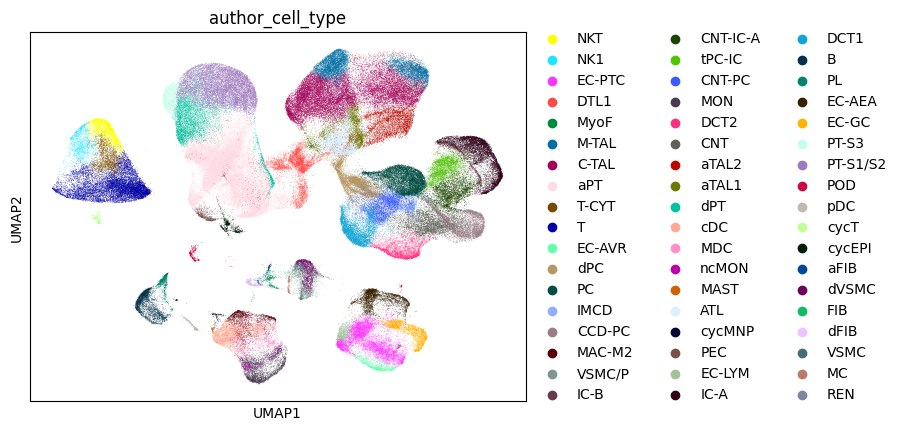

In [7]:
sc.pl.umap(adata, color=["author_cell_type"])

## Find Treg subcluster

In [8]:
T_cell_clusters = ["T", "T-CYT"]

In [10]:
adata_T_cells = adata[
    adata.obs["author_cell_type"].isin(T_cell_clusters)
]
adata_T_cells_raw = adata_raw[
    adata.obs["author_cell_type"].isin(T_cell_clusters)
]

In [11]:
adata_T_cells

View of AnnData object with n_obs × n_vars = 14523 × 31332
    obs: 'orig.ident', 'nCount_RNA', 'SpecimenID', 'LibraryID', 'SampleID', 'Run', 'clusterNumber', 'subclass.l1', 'dataSource', 'diseasetype', 'Race', 'clusterClass', 'organism_ontology_term_id', 'assay_ontology_term_id', 'sampletype', 'disease_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'tissue_ontology_term_id', 'tissue_type', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'Age_binned', 'cell_type_ontology_term_id', 'author_cell_type', 'diabetes_history', 'hypertension', 'eGFR', 'is_primary_data', 'disease_category', 'nFeature_RNA', 'percent.mt', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'index', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length'
    uns: 'batch_condition', 'citation', 'default_embedding', 'schema_refere

In [13]:
adata_T_cells.var.index = adata_T_cells.var["feature_name"].astype(str)
adata_T_cells_raw.var.index = adata_T_cells_raw.var["feature_name"].astype(str)

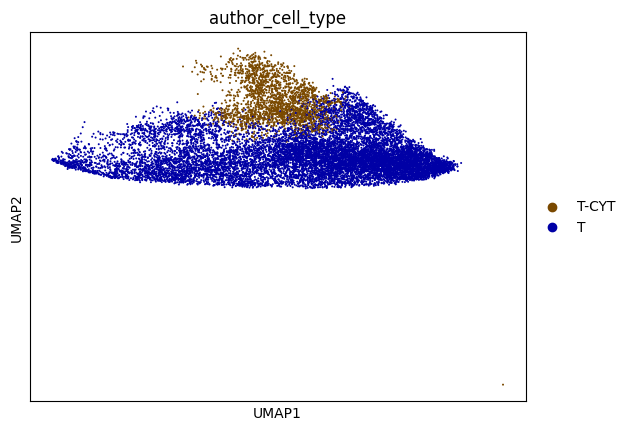

In [14]:
sc.pl.umap(adata_T_cells, color=["author_cell_type"])

In [16]:
sc.pp.pca(adata_T_cells)

In [17]:
sc.pp.neighbors(adata_T_cells)

In [36]:
sc.tl.umap(adata_T_cells)

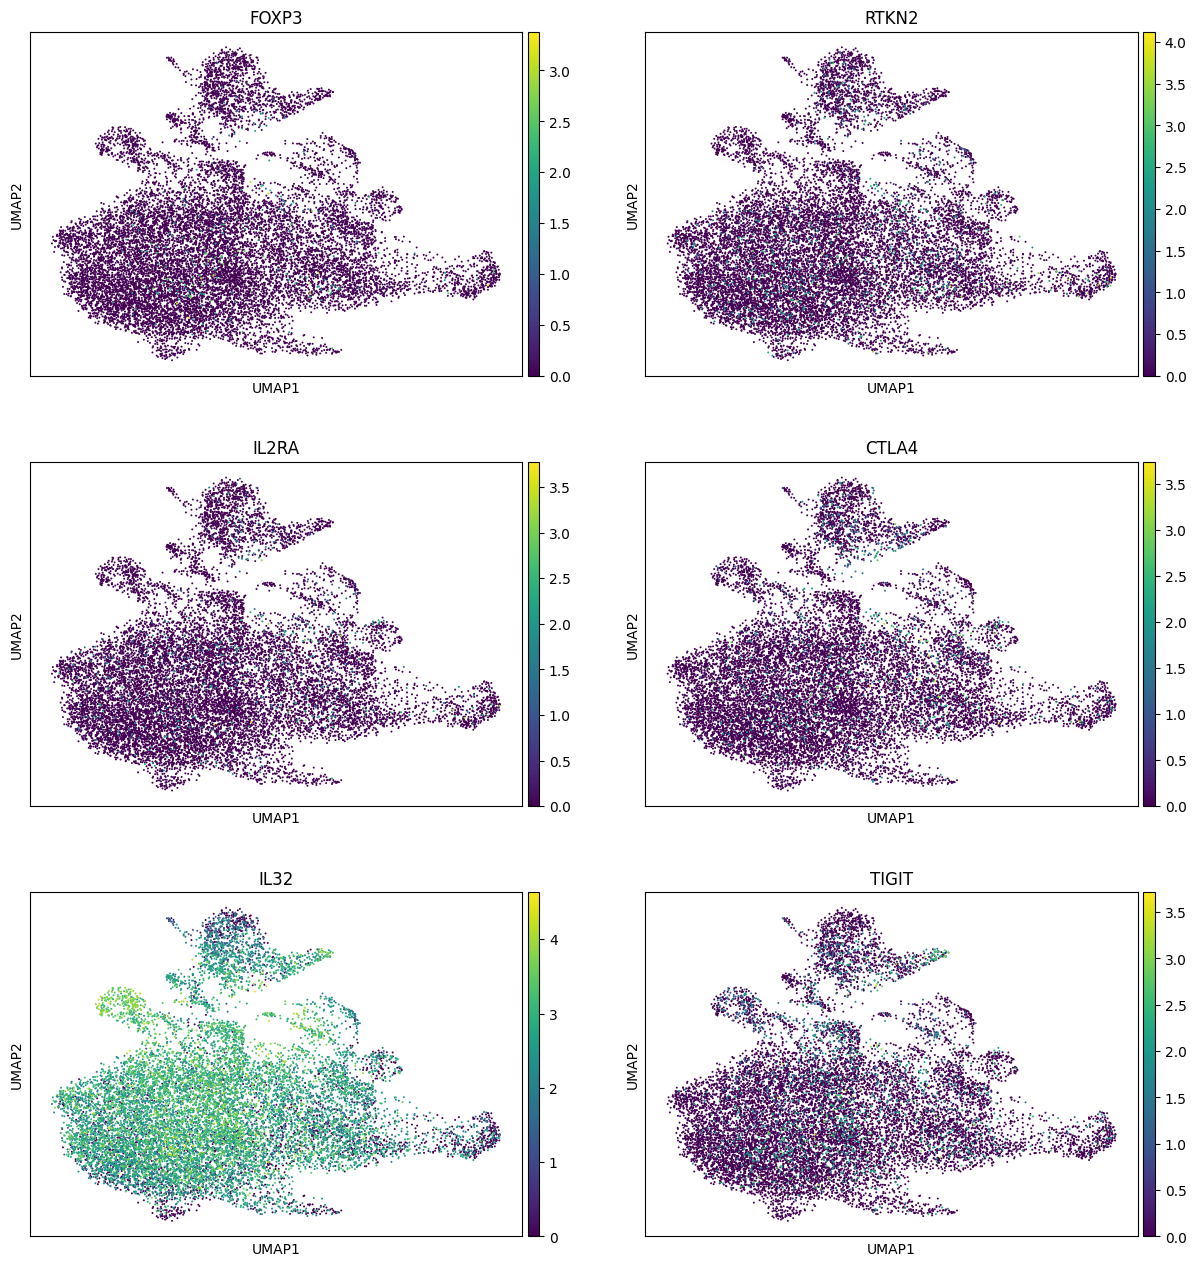

In [42]:
sc.pl.umap(
    adata_T_cells, 
    color=["FOXP3", "RTKN2", "IL2RA", "CTLA4", "IL32", "TIGIT"],
    ncols=2
)

In [54]:
sc.tl.leiden(adata_T_cells, resolution=1.)

In [55]:
adata_T_cells.obs.leiden.value_counts()

leiden
0     1632
1     1468
2     1365
3     1313
4     1283
5     1191
6     1104
7     1029
8      699
9      611
10     507
11     479
12     402
13     365
14     359
15     355
16     198
17     163
Name: count, dtype: int64

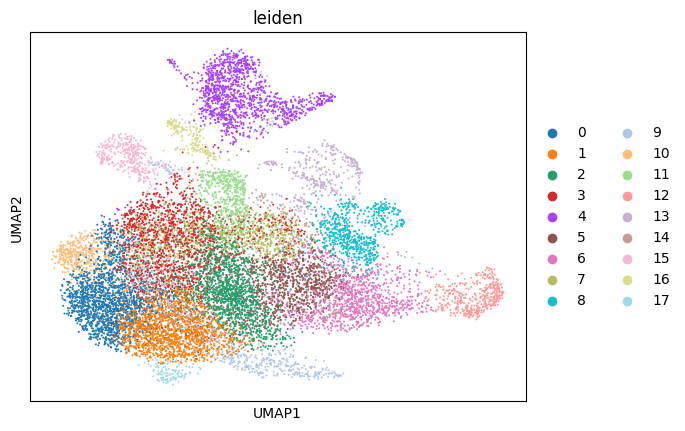

In [56]:
sc.pl.umap(adata_T_cells, color="leiden")

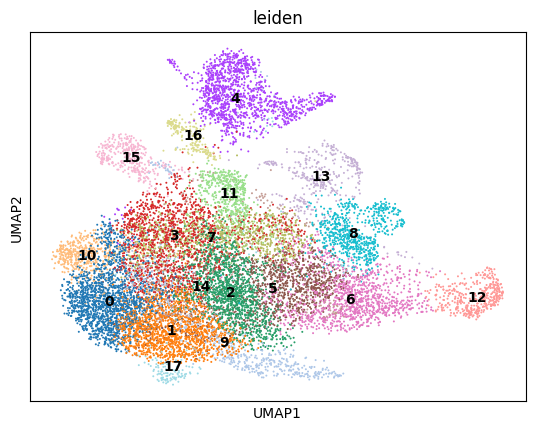

In [57]:
sc.pl.umap(adata_T_cells, color="leiden", legend_loc="on data")

In [58]:
assert adata_T_cells.var.index.equals(adata_T_cells_raw.var.index)
adata_T_cells_raw.obs["leiden"] = adata_T_cells.obs["leiden"]

In [59]:
%autoreload
from pairot.de_testing.testing import calc_pseudobulk_stats
from pairot.de_testing.selection import (
    select_and_combine_de_results,
    sort_and_filter_de_genes_ova,
    sort_and_filter_de_genes_ava,
)

In [60]:
de_res_ova, de_res_ava = calc_pseudobulk_stats(
    adata_T_cells_raw,
    cluster_label="leiden",
    sample_label="SampleID"
)

Calculating AVA AUROC scores: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 153/153 [04:21<00:00,  1.71s/it]


In [61]:
res = select_and_combine_de_results(
    sort_and_filter_de_genes_ova(
        de_res_ova,
        logfc_threshold=0.0,
        aucroc_threshold=0.0
    ),
    sort_and_filter_de_genes_ava(
        de_res_ava,
        logfc_threshold=0.0,
        aucroc_threshold=0.0
    ),
    overlap_threshold=0.3,
    n_genes_ova=None,
    n_genes_ava=None
)

In [62]:
from IPython.display import display

In [63]:
for cluster in np.unique(adata_T_cells_raw.obs.leiden):
    df = res[cluster]
    df = df.head(15)
    print(cluster)
    display(
        df.style
        .format("{:.2f}", subset=["logFC", "auroc"])
        .format("{:.3f}", subset=["adj.P.Val"])
    )
    print()

0


,logFC,adj.P.Val,auroc,reference
ID,,,,
MAL,1.42,0.000,0.55,['all']
LTB,1.23,0.000,0.69,['all']
CCR7,1.15,0.000,0.51,['all']
C1orf162,0.93,0.001,0.52,['all']
ALKBH7,0.93,0.002,0.52,['all']
LDHB,0.92,0.001,0.59,['all']
KLF2,0.90,0.048,0.51,['all']
FLT3LG,0.90,0.006,0.52,['all']
NOSIP,0.89,0.010,0.55,['all']



1


,logFC,adj.P.Val,auroc,reference
ID,,,,
PLK3,0.66,0.018,0.50,['all']
CTSL,0.52,0.021,0.50,['all']
VARS2,0.26,0.043,0.50,['all']
PF4,0.19,0.004,0.50,['all']
CCL19,0.17,0.022,0.50,['all']
GOLGA6L4,0.14,0.008,0.50,['all']
MRAS,0.14,0.035,0.50,['all']
EFNA3,0.13,0.002,0.50,['all']
TENM2,0.13,0.010,0.50,['all']



10


...

,logFC,adj.P.Val,auroc,reference
ID,,,,
FOS,1.54,0.002,0.74,['all']
CD69,1.53,0.001,0.75,['all']
TNFAIP3,1.38,0.001,0.57,['all']
DUSP1,1.31,0.004,0.70,['all']
JUNB,1.25,0.004,0.74,['all']
ANK3,1.20,0.008,0.57,['all']
IMMP2L,1.19,0.004,0.57,['all']
JUN,1.11,0.041,0.69,['all']
KLF2,1.10,0.042,0.57,['all']



8


,logFC,adj.P.Val,auroc,reference
ID,,,,
SYTL3,2.34,0.000,0.74,['all']
CCL4,2.22,0.001,0.60,['all']
CXCR4,2.16,0.000,0.79,['all']
FKBP5,1.97,0.000,0.73,['all']
CRYBG1,1.95,0.000,0.66,['all']
PDE3B,1.74,0.000,0.62,['all']
AOAH,1.72,0.000,0.61,['all']
TSC22D3,1.69,0.000,0.75,['all']
GZMK,1.67,0.004,0.58,['all']



9


,logFC,adj.P.Val,auroc,reference
ID,,,,
AHNAK,1.54,0.000,0.66,['all']
DGKA,1.24,0.000,0.56,['all']
SLFN5,1.22,0.001,0.61,['all']
MYH9,1.16,0.002,0.61,['all']
PURA,1.15,0.000,0.54,['all']
PRPF4B,1.15,0.002,0.61,['all']
SYNE2,1.14,0.008,0.61,['all']
ATP2A3,1.13,0.000,0.55,['all']
SPTAN1,1.13,0.001,0.55,['all']


In [64]:
Treg_markers = ["FOXP3", "RTKN2", "IL2RA", "CTLA4"]


for cluster in np.unique(adata_T_cells_raw.obs.leiden):
    df = res[cluster]
    df.index.name = "ID"
    print(cluster)
    display(
        df
        .reset_index()
        .query(f'`ID` in {Treg_markers}')
        .style
        .format("{:.2f}", subset=["logFC", "auroc"])
        .format("{:.3f}", subset=["adj.P.Val"])
    )
    print()


0


,ID,logFC,adj.P.Val,auroc,reference



1


,ID,logFC,adj.P.Val,auroc,reference



10


...

,ID,logFC,adj.P.Val,auroc,reference



8


,ID,logFC,adj.P.Val,auroc,reference



9


,ID,logFC,adj.P.Val,auroc,reference


In [66]:
adata_T_cells.obs["author_cell_type_fine"] = adata_T_cells.obs["author_cell_type"].astype(str).copy()

adata_T_cells.obs.loc[
    adata_T_cells.obs.leiden.isin(["14"]), 
    "author_cell_type_fine"
] = "CD4 Treg"

In [67]:
adata_T_cells.obs["author_cell_type_fine"] = adata_T_cells.obs["author_cell_type_fine"].astype("category")
adata_T_cells_raw.obs["author_cell_type_fine"] = adata_T_cells.obs["author_cell_type_fine"].astype("category")

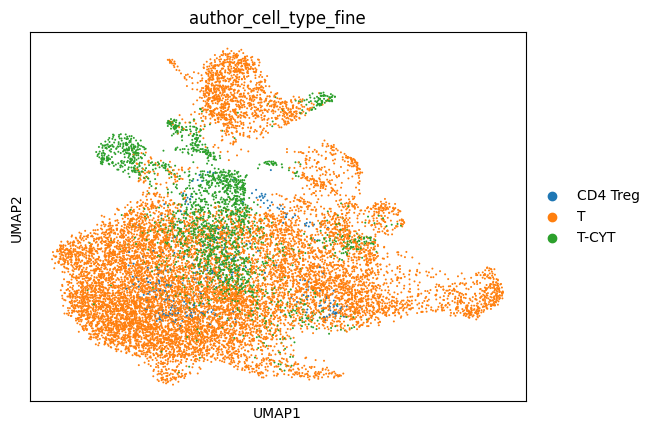

In [68]:
sc.pl.umap(adata_T_cells, color=["author_cell_type_fine"])

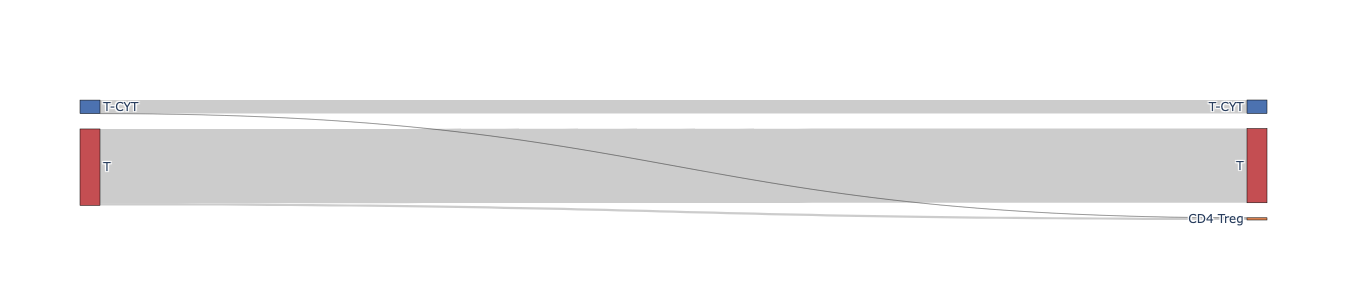

In [71]:
import plotly.graph_objects as go

from itertools import product


clusters_before = adata_T_cells.obs.author_cell_type.unique().tolist()
clusters_after = adata_T_cells.obs.author_cell_type_fine.unique().tolist()
change = {}

for ct in adata_T_cells.obs["author_cell_type"].unique():
    change[ct] = adata_T_cells[adata_T_cells.obs["author_cell_type"] == ct].obs["author_cell_type_fine"].value_counts().to_dict()

fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 15,
      thickness = 20,
      line = dict(color = "black", width = 0.5),
      label = clusters_before + clusters_after,
      color = ["#4C72B0", "#C44E52", "#4C72B0", "#C44E52", "#DD8452"]
    ),
    link = dict(
      source = np.repeat(np.arange(len(clusters_before)), len(clusters_after)),
      target = np.tile(np.arange(len(clusters_before), len(clusters_after) + len(clusters_before)), len(clusters_before)),
      value = [change[ct1].get(ct2, 0) for ct1, ct2 in product(clusters_before, clusters_after)]
  ))])

fig.update_layout(
    width=500, height=300
)
fig.write_image("cluster_change_REF_Treg.svg")

fig.show()

In [72]:
adata_T_cells.obs["author_cell_type_fine"].value_counts(normalize=True)

author_cell_type_fine
T           0.824967
T-CYT       0.150313
CD4 Treg    0.024719
Name: proportion, dtype: float64

In [73]:
adata_T_cells.obs["author_cell_type"].value_counts(normalize=True)

author_cell_type
T        0.849549
T-CYT    0.150451
Name: proportion, dtype: float64

In [74]:
de_res_ova, de_res_ava = calc_pseudobulk_stats(
    adata_T_cells_raw,
    cluster_label="author_cell_type_fine",
    sample_label="SampleID"
)

Calculating AVA AUROC scores: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:07<00:00,  2.62s/it]


In [75]:
res_combined = select_and_combine_de_results(
    sort_and_filter_de_genes_ova(
        de_res_ova,
        logfc_threshold=0.
    ),
    sort_and_filter_de_genes_ava(
        de_res_ava,
        logfc_threshold=0.
    ),
    overlap_threshold=0.3
)

In [76]:
res_combined["CD4 Treg"]

,logFC,adj.P.Val,auroc,reference
ID,,,,
TNFRSF18,2.219903,6.245122e-22,0.679349,[all]
TNFRSF4,2.191821,3.709404e-18,0.686711,[all]
CTLA4,2.014972,4.472074e-22,0.663890,[all]
RTKN2,2.010015,1.514769e-20,0.664356,[all]
FOXP3,1.982041,8.221179e-30,0.648043,[all]
TBC1D4,1.876405,1.202022e-18,0.670678,[all]
ICA1,1.829753,1.631589e-20,0.640757,[all]
TIGIT,1.711798,6.181183e-14,0.713800,[all]
IKZF2,1.528825,6.610279e-11,0.661309,[all]


In [77]:
adata_T_cells.write_h5ad("Treg_subset.h5ad")

## Update cell type annotations

In [78]:
import scanpy as sc

In [79]:
adata_T_cells = sc.read_h5ad("Treg_subset.h5ad")

In [81]:
adata_preprocessed = sc.read_h5ad(
    "/home/ubuntu/data/dataset-similarity/preprocessed/"
    "0f528c8a-a25c-4840-8fa3-d156fa11086f.h5ad",
)

In [82]:
Treg_cells = adata_T_cells.obs[adata_T_cells.obs.author_cell_type_fine == "CD4 Treg"].index.to_numpy()

In [83]:
adata_preprocessed.obs["cell_type_author"] = adata_preprocessed.obs["cell_type_author"].astype(str)
adata_preprocessed.obs.loc[Treg_cells, "cell_type_author"] = "CD4 Treg"
adata_preprocessed.obs["cell_type_author"] = adata_preprocessed.obs["cell_type_author"].astype("category")

In [84]:
adata_preprocessed.obs.cell_type_author.value_counts()

cell_type_author
aPT         29397
C-TAL       21859
PT-S1/S2    13019
T           11981
PC           9376
M-TAL        8855
IC-A         7937
EC-PTC       7873
dPC          7217
dPT          6721
DCT1         5725
aTAL2        5552
ATL          5243
DTL1         5144
CNT-PC       5114
CCD-PC       5072
CNT-IC-A     4803
CNT          4780
PT-S3        3916
aTAL1        3842
cDC          3798
tPC-IC       3715
EC-AEA       3694
MON          3592
DCT2         3404
B            3261
NKT          3171
EC-GC        2827
MDC          2273
MAC-M2       2211
T-CYT        2183
VSMC/P       1938
NK1          1665
dVSMC        1646
IC-B         1305
EC-LYM       1254
EC-AVR       1245
PL           1051
cycEPI        964
dFIB          903
IMCD          847
PEC           775
ncMON         527
POD           462
cycT          421
pDC           376
CD4 Treg      359
MyoF          352
VSMC          317
MC            299
aFIB          276
FIB           252
cycMNP        191
MAST          148
REN        

In [85]:
adata_preprocessed.write_h5ad(
    "/vol/data/dataset-similarity/preprocessed/0f528c8a-a25c-4840-8fa3-d156fa11086f_Treg.h5ad",
    compression="gzip"
)